# Barcode and QR Code Scanner

## Computer Vision Project

This project aims to detect, localize, and decode barcodes and QR codes from images using classical computer vision techniques and barcode decoding libraries.

The implemented pipeline includes:
- preprocessing using grayscale conversion and Gaussian blur
- edge detection using the Canny algorithm
- contour-based region localization
- barcode and QR code decoding using pyzbar
- visualization of detected regions and decoded content
- an interactive graphical interface for image upload and scanning

## Imports and Setup

In [1]:
!apt-get update
!apt-get install -y libzbar0
!pip install pyzbar opencv-python

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,970 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,623 kB]
Get:14 https:/

In [2]:
import os
import cv2
import io
import numpy as np
import matplotlib.pyplot as plt
from pyzbar.pyzbar import decode
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

## Helper Functions

This section defines utility functions used throughout the project for image loading and visualization.

In [3]:
def load_image(image_path):
    """
    Load an image from disk in BGR format.
    Returns None if the image cannot be loaded.
    """
    image = cv2.imread(image_path)
    if image is None:
        print(f"[WARNING] Unable to load image: {image_path}")
        return None
    return image

In [4]:
def show_image(title, image, cmap=None):
    """
    Display an image using matplotlib.
    """
    plt.figure(figsize=(6, 4))
    if len(image.shape) == 3:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.imshow(image_rgb)
    else:
        plt.imshow(image, cmap=cmap if cmap else "gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


In [5]:
def show_side_by_side(image1, title1, image2, title2):
    """
    Display two images side by side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Image 1
    if len(image1.shape) == 3:
        img1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
        axes[0].imshow(img1)
    else:
        axes[0].imshow(image1, cmap="gray")
    axes[0].set_title(title1, fontsize=14, fontweight="bold")
    axes[0].axis("off")

    # Image 2
    if len(image2.shape) == 3:
        img2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
        axes[1].imshow(img2)
    else:
        axes[1].imshow(image2, cmap="gray")
    axes[1].set_title(title2, fontsize=14, fontweight="bold")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

## Preprocessing
In this step, we preprocess the image to improve detection quality.

We convert the image to grayscale to simplify the information and reduce computational complexity.  
Then, we apply Gaussian blur to reduce noise and smooth the image, which helps improve edge detection.

In [6]:
def preprocess_image(image):
    """
    Return grayscale and blurred versions of the image.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    return gray, blurred

## Detection and Localization using Classical Computer Vision
In this step, we use classical computer vision techniques to detect potential regions containing barcodes or QR codes.

The process includes:
- converting the image to grayscale
- applying Canny edge detection to highlight strong edges
- using dilation to connect fragmented edges
- extracting contours to identify candidate regions

Finally, we filter regions based on size to remove noise and keep only relevant areas.

In [7]:
def detect_regions_cv(image):
    """
    Detect potential barcode/QR regions using classical CV techniques.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Edge detection
    edges = cv2.Canny(gray, 50, 150)

    # Dilate edges to connect components
    kernel = np.ones((5,5), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=1)

    # Find contours
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    regions = []

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)

        # Filter small regions (noise)
        if w > 50 and h > 50:
            regions.append((x, y, w, h))

    return edges, dilated, regions

## Decoding

In [8]:
def detect_and_decode(image):
    decoded_objects = decode(image)
    results = []

    for obj in decoded_objects:
        x, y, w, h = obj.rect
        data = obj.data.decode("utf-8", errors="ignore")
        code_type = obj.type

        results.append({
            "type": code_type,
            "data": data,
            "rect": (x, y, w, h)
        })

    return results

## Visualization

In [9]:
def draw_results(image, results):
    """
    Draw bounding boxes and decoded text on a copy of the image.
    """
    output = image.copy()

    for result in results:
        x, y, w, h = result["rect"]
        label = f'{result["type"]}: {result["data"]}'

        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(output, label, (x, max(20, y - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    return output

## Full Pipeline Example

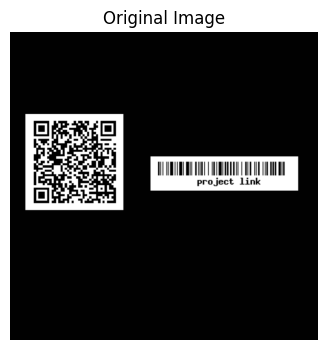

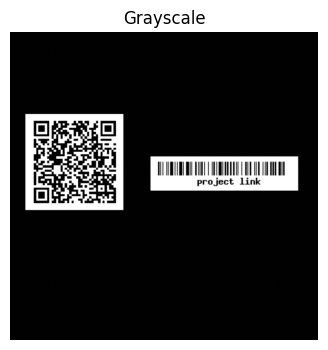

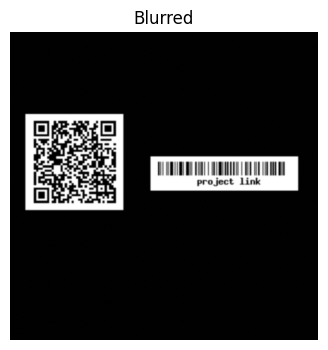

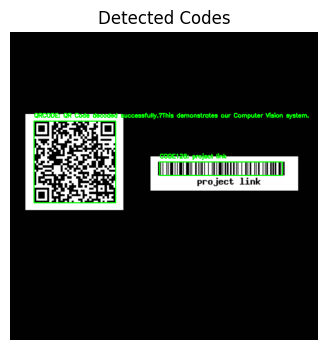

Résultats décodés :
1. Type: QRCODE | Data: QR Code decoded successfully.
This demonstrates our Computer Vision system.
2. Type: CODE128 | Data: project link


In [25]:
image_path = "data/test2.png"
image = load_image(image_path)

gray, blurred = preprocess_image(image)
results = detect_and_decode(image)
output = draw_results(image, results)

show_image("Original Image", image)
show_image("Grayscale", gray, cmap="gray")
show_image("Blurred", blurred, cmap="gray")
show_image("Detected Codes", output)

print("Résultats décodés :")
for i, result in enumerate(results, 1):
    print(f"{i}. Type: {result['type']} | Data: {result['data']}")

## Pipeline Visualization (Technical Analysis)
This section illustrates the intermediate steps of the computer vision pipeline.

We visualize:
- edge detection using the Canny algorithm
- dilation to connect fragmented edges
- detected regions based on contour extraction

These steps help understand how candidate regions containing barcodes and QR codes are identified before decoding.

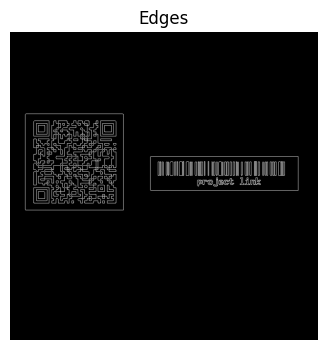

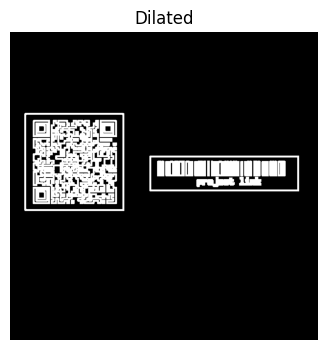

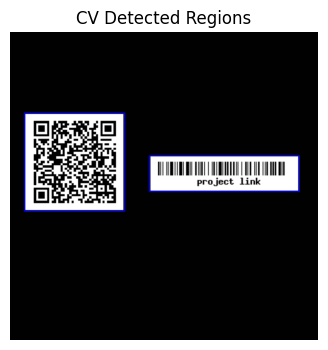

In [26]:
edges, dilated, regions = detect_regions_cv(image)

cv_output = image.copy()

for (x, y, w, h) in regions:
    cv2.rectangle(cv_output, (x, y), (x+w, y+h), (255, 0, 0), 2)

show_image("Edges", edges, cmap="gray")
show_image("Dilated", dilated, cmap="gray")
show_image("CV Detected Regions", cv_output)

## Batch Testing on Multiple Images

In [27]:


def process_dataset(folder_path):
    """
    Process all readable images in a folder and display results.
    Skips files that cannot be loaded.
    """
    valid_extensions = (".png", ".jpg", ".jpeg", ".bmp", ".webp")

    for filename in sorted(os.listdir(folder_path)):
        if not filename.lower().endswith(valid_extensions):
            continue

        image_path = os.path.join(folder_path, filename)
        print(f"\nProcessing: {filename}")

        image = load_image(image_path)
        if image is None:
            print("Image skipped.")
            continue

        try:
            edges, dilated, regions = detect_regions_cv(image)
            results = detect_and_decode(image)
            output = draw_results(image, results)

            show_image("Original", image)
            show_image("Detected Codes", output)

            print("Decoded results:")
            if len(results) == 0:
                print("No code detected.")
            else:
                for i, res in enumerate(results, 1):
                    print(f"{i}. Type: {res['type']} | Data: {res['data']}")

        except Exception as e:
            print(f"[ERROR] Error while processing {filename}: {e}")
            continue


Processing: 2_123 546 789.jpg


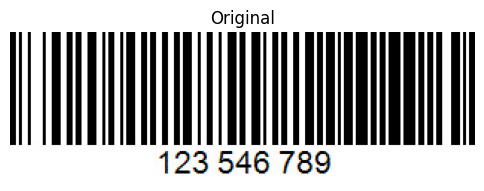

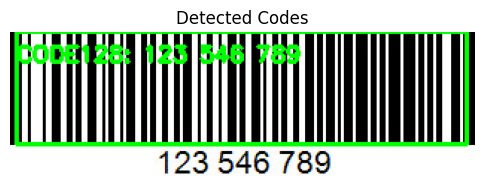

Decoded results:
1. Type: CODE128 | Data: 123 546 789

Processing: qretbar.png


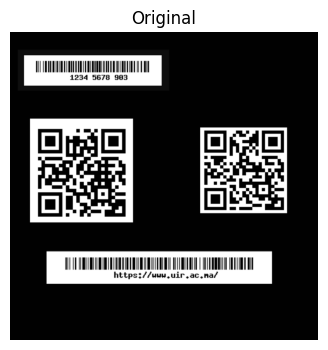

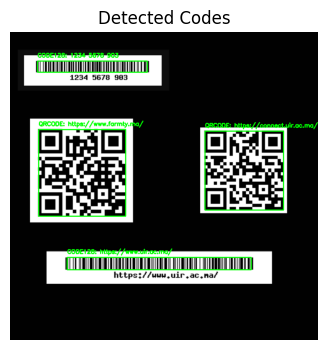

Decoded results:
1. Type: QRCODE | Data: https://connect.uir.ac.ma/
2. Type: QRCODE | Data: https://www.farmty.ma/
3. Type: CODE128 | Data: https://www.uir.ac.ma/
4. Type: CODE128 | Data: 1234 5678 903

Processing: test1.jpg


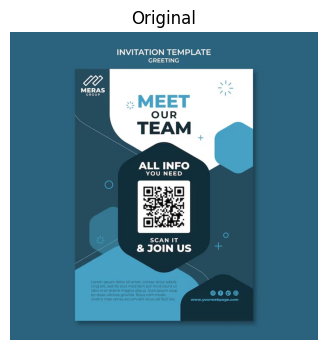

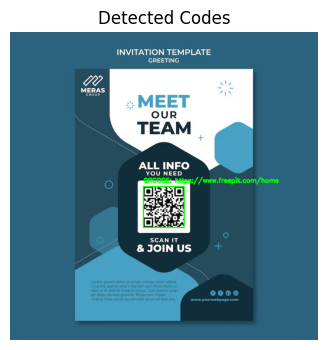

Decoded results:
1. Type: QRCODE | Data: https://www.freepik.com/home

Processing: test2.png


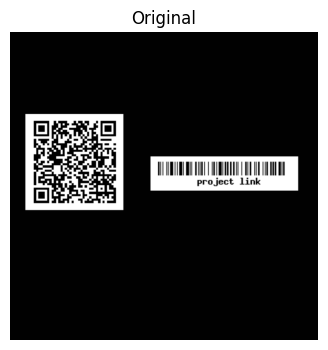

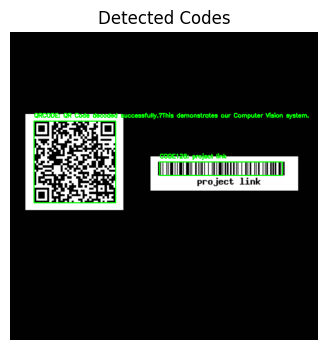

Decoded results:
1. Type: QRCODE | Data: QR Code decoded successfully.
This demonstrates our Computer Vision system.
2. Type: CODE128 | Data: project link

Processing: test4.png


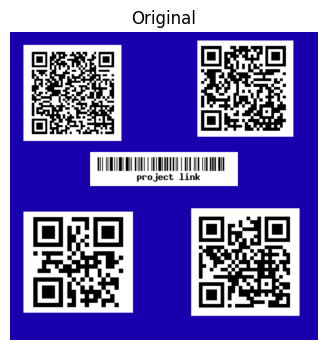

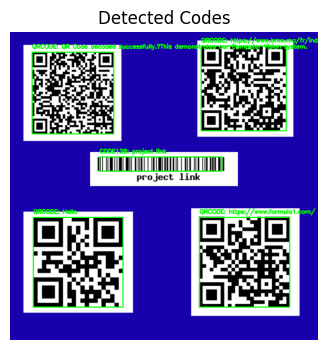

Decoded results:
1. Type: QRCODE | Data: QR Code decoded successfully.
This demonstrates our Computer Vision system.
2. Type: QRCODE | Data: https://www.bmw.ma/fr/index.html
3. Type: QRCODE | Data: https://www.formula1.com/
4. Type: QRCODE | Data: Hello
5. Type: CODE128 | Data: project link


In [28]:
process_dataset("data/")

## Interactive Interface

This section presents the final user-oriented interface of the project.

The interface allows the user to upload an image, run the scanner, and directly visualize detected codes and decoded content.

In [14]:
def load_uploaded_image(uploader):
    """
    Load image from ipywidgets FileUpload.
    Returns image in BGR format or None.
    """
    if not uploader.value:
        return None

    uploaded_file = list(uploader.value.values())[0]
    content = uploaded_file["content"]

    file_bytes = np.frombuffer(content, np.uint8)
    image = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    return image

In [15]:
# Title
title = widgets.HTML(
    value="""
    <div style="
        background: linear-gradient(90deg, #1f2937, #111827);
        padding: 18px;
        border-radius: 14px;
        color: white;
        text-align: center;
        font-size: 26px;
        font-weight: bold;
        box-shadow: 0 4px 12px rgba(0,0,0,0.2);
        margin-bottom: 12px;
    ">
        Barcode & QR Code Scanner
    </div>
    """
)

subtitle = widgets.HTML(
    value="""
    <div style="
        padding: 10px;
        border-radius: 10px;
        background-color: #f3f4f6;
        color: #374151;
        font-size: 14px;
        margin-bottom: 12px;
        border: 1px solid #e5e7eb;
    ">
        Upload an image, then click <b>Run Scanner</b> to detect and decode QR codes and barcodes.
    </div>
    """
)

uploader = widgets.FileUpload(
    accept=".png,.jpg,.jpeg,.bmp,.webp",
    multiple=False
)

scan_button = widgets.Button(
    description="Run Scanner",
    button_style="success",
    icon="search",
    layout=widgets.Layout(width="180px", height="42px")
)

clear_button = widgets.Button(
    description="Clear",
    button_style="warning",
    icon="trash",
    layout=widgets.Layout(width="120px", height="42px")
)

status_box = widgets.HTML(
    value="""
    <div style="
        padding: 10px;
        background-color: #eef2ff;
        border: 1px solid #c7d2fe;
        border-radius: 10px;
        color: #312e81;
        font-size: 14px;
        margin-top: 10px;
    ">
        Waiting for image upload...
    </div>
    """
)

output_area = widgets.Output()

button_row = widgets.HBox(
    [scan_button, clear_button],
    layout=widgets.Layout(gap="10px", margin="10px 0 10px 0")
)

container = widgets.VBox(
    [title, subtitle, uploader, button_row, status_box, output_area],
    layout=widgets.Layout(
        width="100%",
        padding="16px",
        border="1px solid #e5e7eb",
        border_radius="16px"
    )
)

In [16]:
def on_scan_clicked(b):
    with output_area:
        clear_output()

        image = load_uploaded_image(uploader)

        if image is None:
            status_box.value = """
            <div style="
                padding: 10px;
                background-color: #fef2f2;
                border: 1px solid #fecaca;
                border-radius: 10px;
                color: #991b1b;
                font-size: 14px;
                margin-top: 10px;
            ">
                No image uploaded. Please upload an image first.
            </div>
            """
            return

        status_box.value = """
        <div style="
            padding: 10px;
            background-color: #ecfdf5;
            border: 1px solid #a7f3d0;
            border-radius: 10px;
            color: #065f46;
            font-size: 14px;
            margin-top: 10px;
        ">
            Processing image...
        </div>
        """

        try:
            gray, blurred = preprocess_image(image)
            edges, dilated, regions = detect_regions_cv(image)
            results = detect_and_decode(image)
            output = draw_results(image, results)

            show_side_by_side(image, "Original Image", output, "Detected Codes")

            print("Decoded results:")
            if len(results) == 0:
                print("No code detected.")
            else:
                for i, res in enumerate(results, 1):
                    print(f"{i}. {res['type']} -> {res['data']}")

            status_box.value = f"""
            <div style="
                padding: 10px;
                background-color: #ecfdf5;
                border: 1px solid #a7f3d0;
                border-radius: 10px;
                color: #065f46;
                font-size: 14px;
                margin-top: 10px;
            ">
                Scan complete. Detected <b>{len(results)}</b> code(s).
            </div>
            """

        except Exception as e:
            status_box.value = f"""
            <div style="
                padding: 10px;
                background-color: #fef2f2;
                border: 1px solid #fecaca;
                border-radius: 10px;
                color: #991b1b;
                font-size: 14px;
                margin-top: 10px;
            ">
                Error while processing image: {str(e)}
            </div>
            """

def on_clear_clicked(b):
    uploader.value.clear()
    uploader._counter = 0
    status_box.value = """
    <div style="
        padding: 10px;
        background-color: #eef2ff;
        border: 1px solid #c7d2fe;
        border-radius: 10px;
        color: #312e81;
        font-size: 14px;
        margin-top: 10px;
    ">
        Waiting for image upload...
    </div>
    """
    with output_area:
        clear_output()

scan_button.on_click(on_scan_clicked)
clear_button.on_click(on_clear_clicked)

## Interactive Interface

In [17]:
display(container)

## Conclusion

This project demonstrates a complete pipeline for detecting and decoding barcodes and QR codes using both classical computer vision and decoding libraries.

The system is robust, supports multiple images, and includes a user-friendly interface.

Future work could include:
- real-time camera detection
- deep learning-based detection
- mobile deployment